In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q -U diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

print("Model loaded successfully on", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.5 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully on Tesla T4


  0%|          | 0/20 [00:00<?, ?it/s]

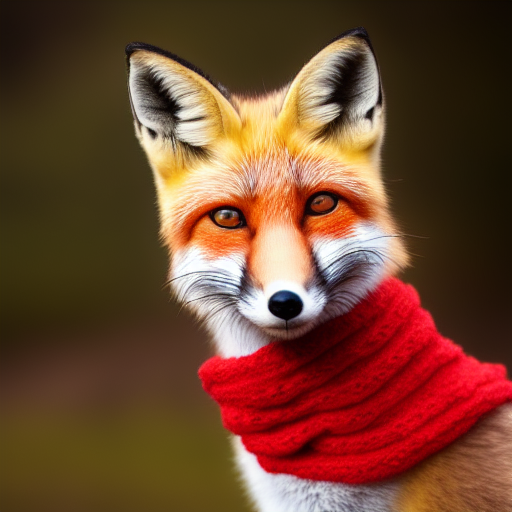

In [ ]:
prompt = "ultra-detailed portrait of a red fox wearing a tiny scarf, cinematic lighting, 35mm"
negative_prompt = "blurry, lowres, jpeg artifacts, text, watermark"

generator = torch.Generator(device="cuda").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=7.0,
    height=512,
    width=512,
    generator=generator
).images[0]

image

  0%|          | 0/30 [00:00<?, ?it/s]

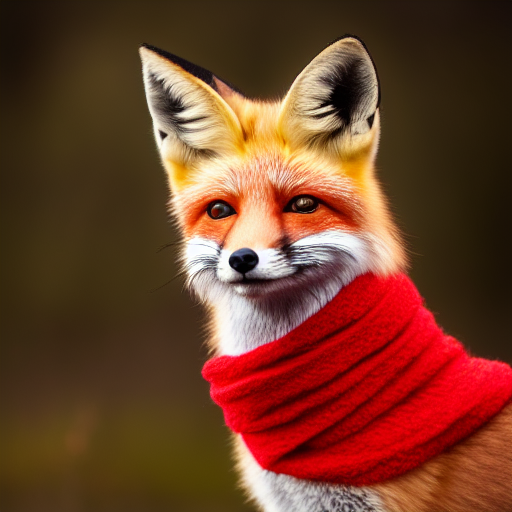

In [ ]:
prompt = "ultra-detailed portrait of a red fox wearing a tiny scarf, cinematic lighting, 35mm"
negative_prompt = "blurry, lowres, jpeg artifacts, text, watermark"

generator = torch.Generator(device="cuda").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    height=512,
    width=512,
    generator=generator
).images[0]

image

  0%|          | 0/20 [00:00<?, ?it/s]

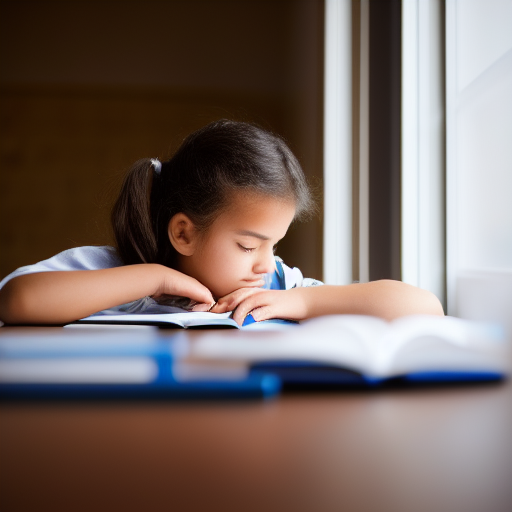

In [ ]:
prompt = "a focused student sitting alone in a classroom, reading a book, soft natural lighting, realistic, high detail, depth of field"
negative_prompt = "blurry, lowres, bad anatomy, distorted, extra limbs, text, watermark"

generator = torch.Generator(device="cuda").manual_seed(123)

image_with_neg = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=7.0,
    height=512,
    width=512,
    generator=generator
).images[0]

image_with_neg

  0%|          | 0/20 [00:00<?, ?it/s]

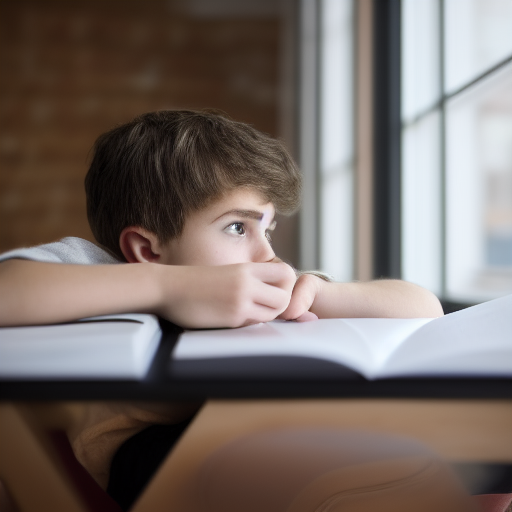

In [ ]:
generator = torch.Generator(device="cuda").manual_seed(123)

image_without_neg = pipe(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=7.0,
    height=512,
    width=512,
    generator=generator
).images[0]

image_without_neg

  0%|          | 0/20 [00:00<?, ?it/s]

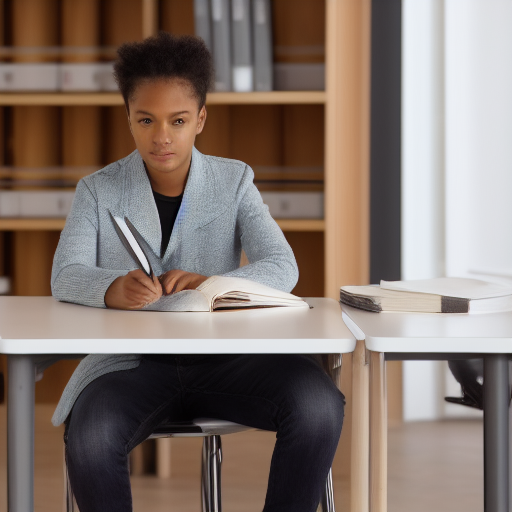

In [ ]:
prompt = "a student sitting alone at a classroom desk, clearly reading an open book in front of them, eyes directed at the book, both hands resting naturally near the pages, realistic classroom scene, soft natural window light, high detail, photorealistic"
negative_prompt = "sleeping, looking out the window, blurry, lowres, distorted hands, extra fingers, malformed hands, bad anatomy, warped desk, text, watermark"

generator = torch.Generator(device="cuda").manual_seed(123)

image_with_neg = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=7.0,
    height=512,
    width=512,
    generator=generator
).images[0]

image_with_neg